In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

In [3]:
x_train = train.drop(columns=["NObeyesdad"])
y_train = train["NObeyesdad"]
x_test = test.drop(columns=["NObeyesdad"])
y_test = test["NObeyesdad"]

In [4]:
from sklearnex import patch_sklearn
patch_sklearn()

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [5]:
param_grid = {
    'n_estimators': [250, 300, 350, 400],
    'max_depth': [20, 25, 30, None],
    'min_samples_split': [3, 4, 5, 6],
    'min_samples_leaf': [2, 3, 5],
    'max_features': [0.5, 0.6, 0.7],
    'bootstrap': [True, False],
}


rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

joblib.dump(best_rf_model, "../models/random_forest_best_model.pkl")

y_train_pred_rf = best_rf_model.predict(x_train)
y_test_pred_rf = best_rf_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best Parameters Found: {'bootstrap': False, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 350}
Training Accuracy: 1.0
Testing Accuracy: 0.9527186761229315


In [6]:
param_grid = {
    'n_estimators': [300, 400],
    'max_depth': [12, 15, 18],
    'min_samples_leaf': [2, 3, 4],
    'max_features': [0.45, 0.5],
    'bootstrap': [False],
    'max_samples': [None],
    'criterion': ['gini', 'entropy']
}


rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

joblib.dump(best_rf_model, "../models/random_forest_best_model.pkl")

y_train_pred_rf = best_rf_model.predict(x_train)
y_test_pred_rf = best_rf_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters Found: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 15, 'max_features': 0.5, 'max_samples': None, 'min_samples_leaf': 2, 'n_estimators': 300}
Training Accuracy: 1.0
Testing Accuracy: 0.9598108747044918


In [7]:
param_grid = {
    'n_estimators': [250, 300, 350, 400],
    'max_depth': [13, 14, 15, 16, 17],
    'min_samples_leaf': [1, 2],
    'max_features': [0.45, 0.5, 0.55],
    'criterion': ['entropy'],
    'bootstrap': [False]
}



rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_


joblib.dump(best_rf_model, "../models/random_forest_best_model.pkl")

y_train_pred_rf = best_rf_model.predict(x_train)
y_test_pred_rf = best_rf_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters Found: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 13, 'max_features': 0.55, 'min_samples_leaf': 1, 'n_estimators': 350}
Training Accuracy: 1.0
Testing Accuracy: 0.9598108747044918



Detailed TEST Accuracy Report for Random Forest (Tuned Model):

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.85      0.97      0.90        58
           2       0.96      0.97      0.96        70
           3       1.00      0.98      0.99        60
           4       1.00      0.98      0.99        65
           5       0.95      0.90      0.92        58
           6       0.98      0.98      0.98        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



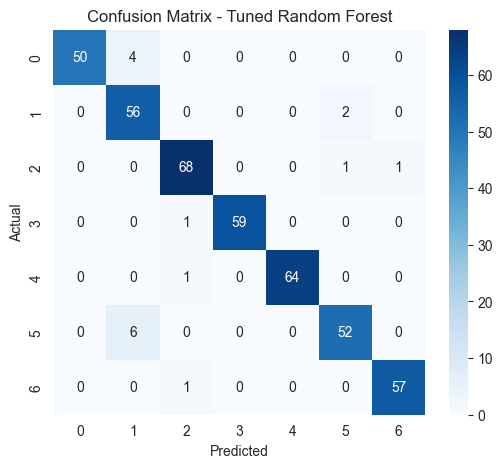

In [8]:
print("\nDetailed TEST Accuracy Report for Random Forest (Tuned Model):\n")
print(classification_report(y_test, y_test_pred_rf))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()